In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

folder = Path("transformations")

soc_files = list(folder.glob("*.soc"))
ttl_files = list(folder.glob("*.ttl"))

soc_stems = [f.stem for f in soc_files]
ttl_stems = [f.stem for f in ttl_files]

common_stems = sorted(set(soc_stems).intersection(ttl_stems))

soc_only = sorted(set(soc_stems) - set(ttl_stems))
ttl_only = sorted(set(ttl_stems) - set(soc_stems))

if soc_only:
    print("These have .soc but no matching .ttl:", ", ".join(soc_only))
if ttl_only:
    print("These have .ttl but no matching .soc:", ", ".join(ttl_only))

soc_map = {f.stem: f for f in soc_files}
ttl_map = {f.stem: f for f in ttl_files}


def count_nonempty_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        return sum(1 for line in f if line.strip())


text_rows = [count_nonempty_lines(soc_map[stem]) for stem in common_stems]
turtle_rows = [count_nonempty_lines(ttl_map[stem]) for stem in common_stems]

df = pd.DataFrame({
    "file_stem": common_stems,
    "Text_rows": text_rows,
    "Turtle_rows": turtle_rows
})

# Scale data
X = df[["Text_rows", "Turtle_rows"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
wss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init=25, random_state=123)
    km.fit(X_scaled)
    wss.append(km.inertia_)

elbow_df = pd.DataFrame({
    "k": range(1, 11),
    "wss": wss
})

# K-means with 3 clusters
km = KMeans(n_clusters=3, n_init=25, random_state=123)
df["cluster"] = km.fit_predict(X_scaled) + 1  # +1 to mimic R labels

# Expansion ratio
df["expansion_ratio"] = df["Turtle_rows"] / df["Text_rows"]

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

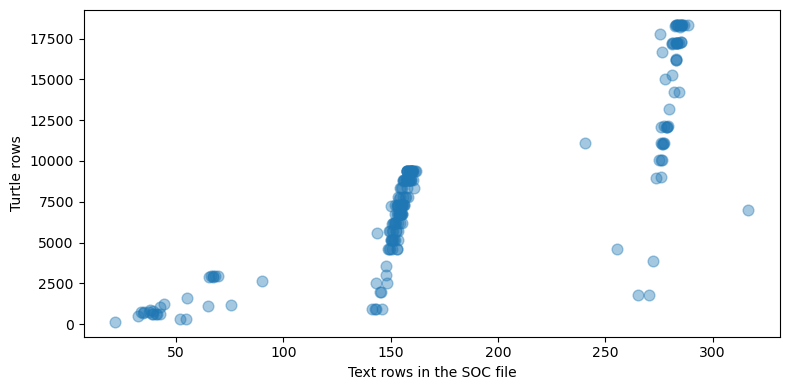

In [2]:
# Plot Text_rows vs Turtle_rows with jitter
plt.figure(figsize=(8, 4))

# Random seed
np.random.seed(42)

x_jitter = df["Text_rows"] + np.random.normal(0, 1.5, size=len(df))
y_jitter = df["Turtle_rows"] + np.random.normal(0, 1.5, size=len(df))

plt.scatter(
    x_jitter, 
    y_jitter, 
    alpha=0.4,
    s=60
)

plt.xlabel("Text rows in the SOC file")
plt.ylabel("Turtle rows")
plt.tight_layout()
plt.savefig("text_vs_turtle.png", dpi=300)
plt.show()

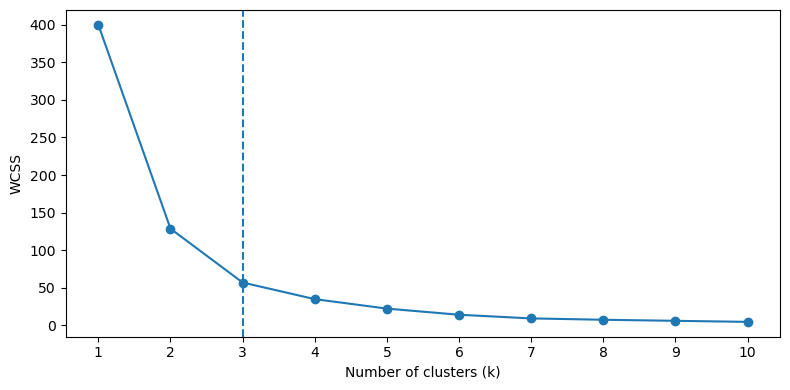

In [3]:
# Plot elbow-method
plt.figure(figsize=(8, 4))
plt.plot(elbow_df["k"], elbow_df["wss"], marker="o")
plt.axvline(x=3, linestyle="--")
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.tight_layout()
plt.savefig("elbow_method.png", dpi=300)
plt.show()

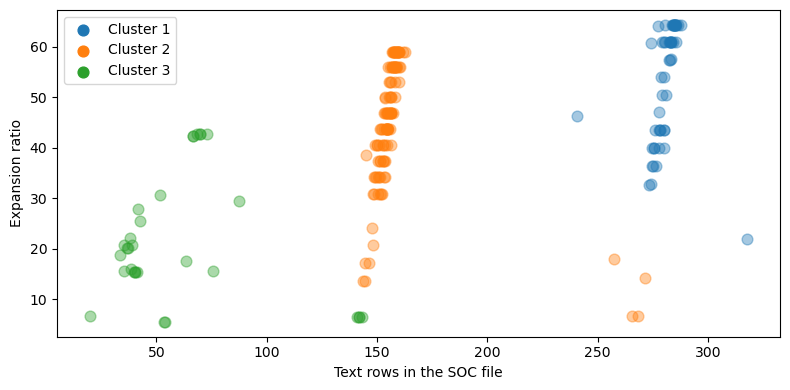

In [4]:
# Plot expansion ratio
plt.figure(figsize=(8, 4))

# Random seed
np.random.seed(42)

for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]

    # Add small random noise to X to prevent perfect overlap
    x_jitter = subset["Text_rows"] + np.random.normal(0, 1.5, size=len(subset))
    
    plt.scatter(
        x_jitter,
        subset["expansion_ratio"],
        s=60,
        alpha=0.4,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Text rows in the SOC file")
plt.ylabel("Expansion ratio")

leg = plt.legend()
for handle in leg.legend_handles:
    handle.set_alpha(1.0)

plt.tight_layout()
plt.savefig("efficiency_test_ratio.png", dpi=300)
plt.show()

C:\Users\conny\AppData\Local\Temp\ipykernel_14748\1506451300.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(


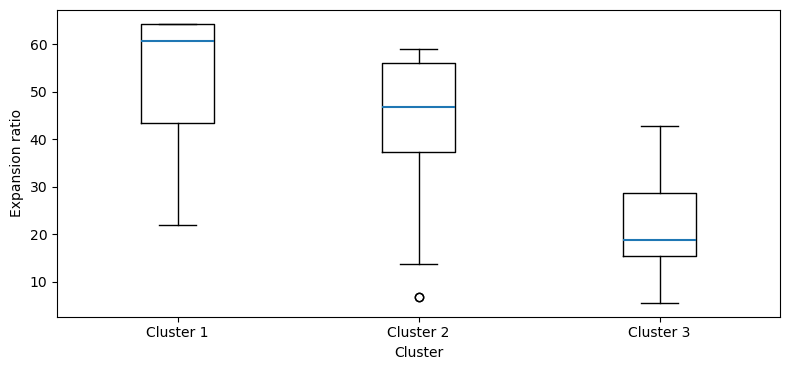

In [10]:
# Boxplots
plt.figure(figsize=(8, 3.8))
clusters = sorted(df["cluster"].unique())
data_boxplot = [df[df["cluster"] == c]["expansion_ratio"] for c in clusters]
bplot = plt.boxplot(
        data_boxplot, 
        labels=[f"Cluster {c}" for c in clusters],
        patch_artist=False,
        medianprops={"color": "#1f77b4", "linewidth": 1.5}
)

plt.xlabel("Cluster")
plt.ylabel("Expansion ratio")
plt.tight_layout()
plt.savefig("expansion_boxplot.png", dpi=300)
plt.show()

In [6]:
boxplot_metrics = df.groupby("cluster")["expansion_ratio"].describe()
print(boxplot_metrics)

boxplot_metrics.style.format(precision=2).to_latex(
    "boxplot_metrics.tex",
    hrules=True
)

         count       mean        std        min        25%        50%  \
cluster                                                                 
1         53.0  53.343853  11.458864  21.927673  43.485612  60.720000   
2        116.0  44.656341  12.569232   6.711610  37.401316  46.889883   
3         31.0  21.346596  12.625468   5.547170  15.425000  18.685714   

               75%        max  
cluster                        
1        64.282686  64.329825  
2        56.069620  59.044025  
3        28.594356  42.724638  
